In [7]:
import geopandas as gpd
import sys
# sys.path.append('/home/lpsha/s154446/fractality/dual_graph_algo/')
# import dual_conti

from pyrosm import OSM, get_data
import osmnx as ox
import momepy

import matplotlib.pyplot as plt

import numpy as np

# create a polygon of the bounding box
from shapely.geometry import box
from shapely.geometry import LineString

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import contextily as cx

# map matched

In [3]:
paths = gpd.read_file("/home/lpsha/s154446/fractality/data/traj/Trajectories_0.shp")
paths=paths.to_crs('3857')

In [4]:
paths_proj = paths.to_crs('EPSG:4326')
minx, miny, maxx, maxy = paths_proj.total_bounds  # returns (minx, miny, maxx, maxy)
bbox_polygon = box(minx, miny, maxx, maxy)

In [4]:
G = ox.graph.graph_from_polygon(bbox_polygon)

In [5]:
from importlib import reload
reload(dual_conti)
gdf_merged, _, _, _ = dual_conti.get_dual_dir_con(t_buffer=10, a_threshold=20, data=G, enforce_degree2=False)
gdf_merged.crs = 3857

osmnx graph


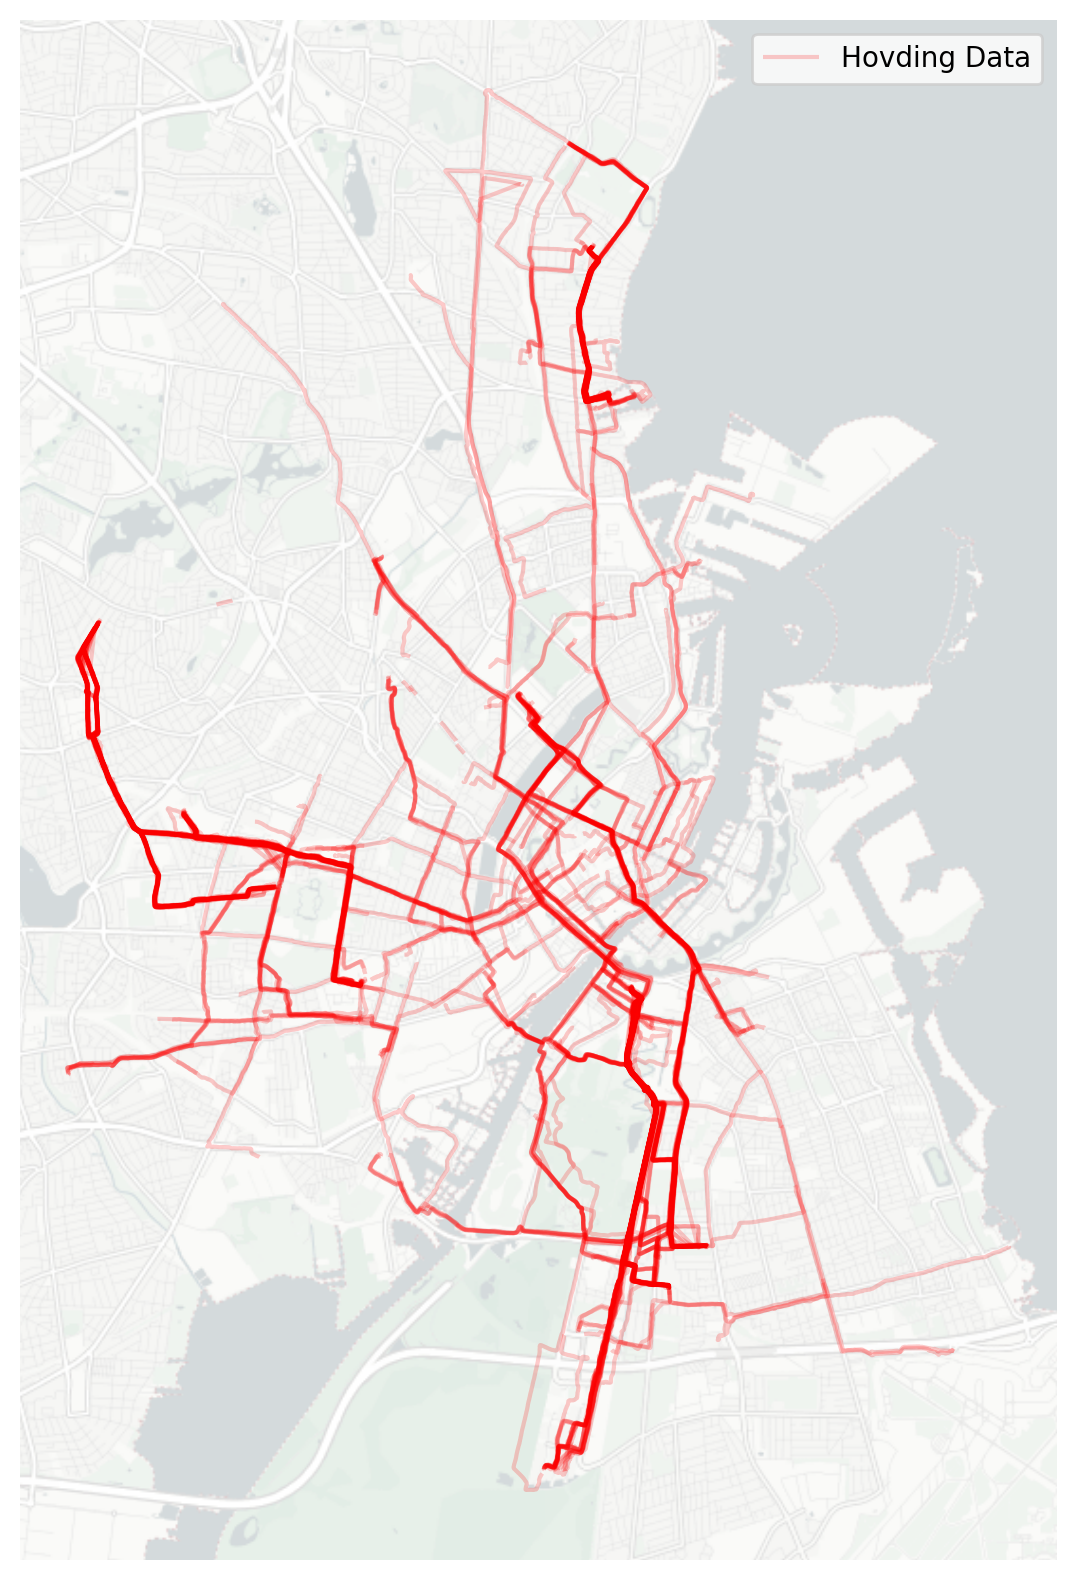

In [11]:
# gdf_merged['degree_log'] = gdf_merged.degree.apply(np.log10)
fig, ax = plt.subplots(figsize=(10,10),dpi=200)
# gdf_merged.plot(column='degree_log', cmap='Blues', ax=ax, linewidth=1,legend=True,vmin=1,alpha=0.7)
paths.plot(ax=ax,color='red',alpha=0.2,label="Hovding Data")
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels,zoom='auto', attribution=False)
plt.legend()
ax.axis('off')
plt.show()

In [43]:
# project roads once
roads_proj = gdf_merged.to_crs(epsg=3857)
roads_buffered = roads_proj.geometry.buffer(5)
roads_buffered_gdf = gpd.GeoDataFrame(
    roads_proj.drop(columns='geometry'), 
    geometry=roads_buffered, 
    crs=roads_proj.crs
)

In [44]:
def degree_sequence(path_geom):
    # project path
    path_proj = (
        gpd.GeoSeries([path_geom], crs=paths.crs)
        .to_crs(roads_proj.crs)
        .iloc[0]
    )

    # proportional sampling (≈1 point every 5 m)
    num_points = max(int(path_proj.length // 5), 2)
    distances = np.linspace(0, path_proj.length, num_points)

    # sample points
    points = [path_proj.interpolate(d) for d in distances]
    points_gdf = gpd.GeoDataFrame(geometry=points, crs=roads_proj.crs)

    # buffer points
    points_buffered = gpd.GeoDataFrame(
        geometry=points_gdf.geometry.buffer(5),
        crs=roads_proj.crs
    )

    # spatial join
    joined = gpd.sjoin(
        points_buffered,
        roads_buffered_gdf[['geometry', 'degree']],
        how='left',
        predicate='intersects'
    )

    # return clean degree sequence
    return joined['degree'].dropna().tolist()

In [58]:
paths['degree_seq'] = paths['geometry'].apply(degree_sequence)
paths['x'] = paths['degree_seq'].apply(lambda x: np.arange(len(x)) / len(x))

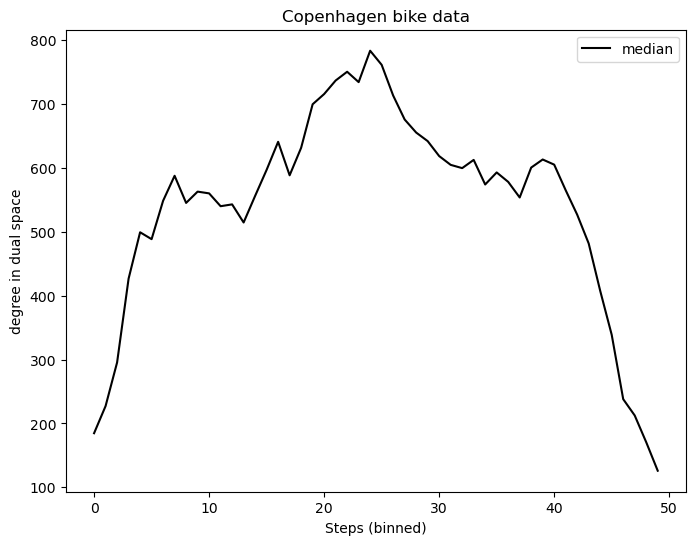

In [ ]:
fig, ax = plt.subplots(figsize=(8,6),dpi=100)

n_bins = 50
xs_arr = np.concatenate(paths['x'].values)
ys_arr = np.concatenate(paths['degree_seq'].values)
bins = np.linspace(0, 1, n_bins + 1)
idx = np.digitize(xs_arr, bins) - 1
bin_means = np.array([np.mean(ys_arr[idx == i]) for i in range(n_bins)])
ax.plot(bin_means,label='median',color='k')

plt.legend()
plt.ylabel('degree in dual space')
plt.xlabel('Steps (binned)')

plt.title('Copenhagen bike data')
plt.show()

# OSM route

In [53]:
def get_osm_route(lon1, lat1, lon2, lat2):
    url = (
        "http://router.project-osrm.org/route/v1/walking/"
        f"{lon1},{lat1};{lon2},{lat2}"
    )
    params = {
        "overview": "simplified",
        "geometries": "geojson",
        "steps": "true",
        # "profile": "bike"
    }

    r = requests.get(url, params=params)
    r.raise_for_status()

    route = r.json()["routes"][0]
    geometry = route["geometry"]        # GeoJSON LineString

    return LineString(geometry["coordinates"]), r.json()['routes'][0]['legs'][0]['steps'][0]['mode'], r.json()

In [48]:
# paths_proj = paths.to_crs('EPSG:4326')

# for index, row in tqdm(paths_proj.iterrows()):
#     geom = row.geometry
#     paths.loc[index, 'osm_route'] = get_osm_route(geom.coords[0][0], geom.coords[0][1], geom.coords[-1][0], geom.coords[-1][1])

In [ ]:
geom=paths_proj.sample(1).geometry.iloc[0]
lon1,lat1,lon2,lat2 = geom.coords[0][0], geom.coords[0][1], geom.coords[-1][0], geom.coords[-1][1]
line, mode, full = get_osm_route(lon1, lat1, lon2, lat2)
print(mode)

driving


In [52]:
# paths = paths.set_geometry('osm_route')
paths=paths.set_crs('EPSG:4326')
paths=paths.to_crs(epsg=3857)
paths['osm_degree_seq'] = paths['osm_route'].apply(degree_sequence)
paths['x_osm'] = paths['osm_degree_seq'].apply(lambda x: np.arange(len(x)) / len(x))

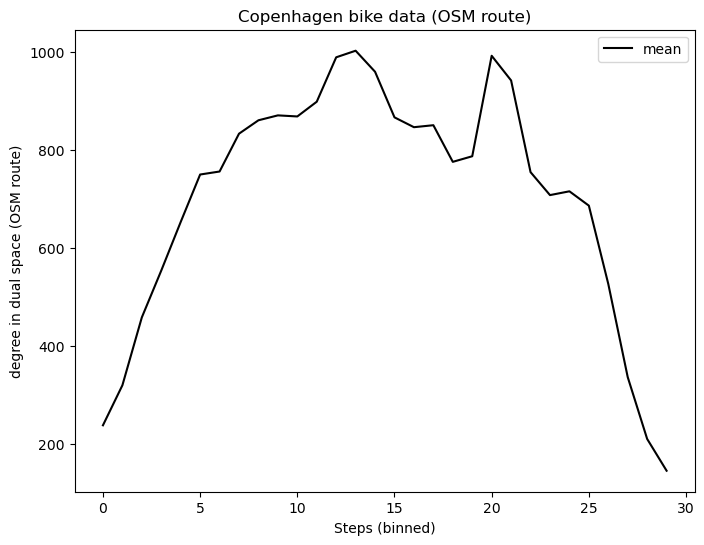

In [57]:
# plot 
fig, ax = plt.subplots(figsize=(8,6),dpi=100)
n_bins = 30
xs_arr = np.concatenate(paths['x_osm'].values)
ys_arr = np.concatenate(paths['osm_degree_seq'].values)
bins = np.linspace(0, 1, n_bins + 1)
idx = np.digitize(xs_arr, bins) - 1
bin_means = np.array([np.mean(ys_arr[idx == i]) for i in range(n_bins)])
ax.plot(bin_means,label='mean',color='k')
plt.legend()
plt.ylabel('degree in dual space (OSM route)')
plt.xlabel('Steps (binned)')
plt.title('Copenhagen bike data (OSM route)')
plt.show()

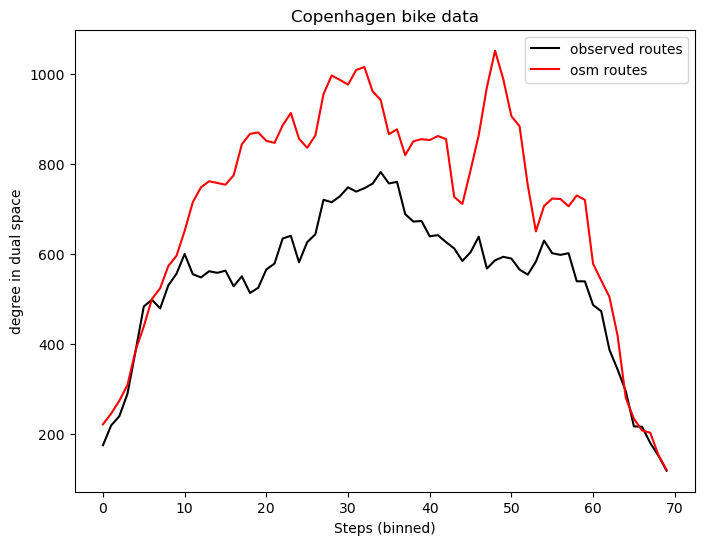

In [64]:
fig, ax = plt.subplots(figsize=(8,6),dpi=100)

n_bins = 70
xs_arr = np.concatenate(paths['x'].values)
ys_arr = np.concatenate(paths['degree_seq'].values)
bins = np.linspace(0, 1, n_bins + 1)
idx = np.digitize(xs_arr, bins) - 1
bin_means = np.array([np.mean(ys_arr[idx == i]) for i in range(n_bins)])
ax.plot(bin_means,label='observed routes',color='k')


xs_arr = np.concatenate(paths['x_osm'].values)
ys_arr = np.concatenate(paths['osm_degree_seq'].values)
bins = np.linspace(0, 1, n_bins + 1)
idx = np.digitize(xs_arr, bins) - 1
bin_means = np.array([np.mean(ys_arr[idx == i]) for i in range(n_bins)])
ax.plot(bin_means,label='osm routes',color='red')

plt.legend()
plt.ylabel('degree in dual space')
plt.xlabel('Steps (binned)')
plt.title('Copenhagen bike data')
plt.show()

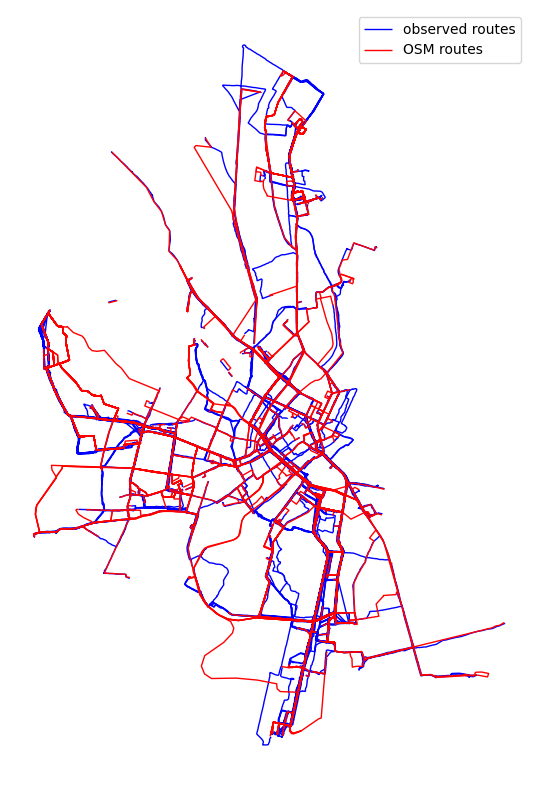

In [194]:
import geopandas as gpd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoSeries(paths['geometry']).plot(ax=ax, color='blue', linewidth=1, label='observed routes')
gpd.GeoSeries(paths['osm_route']).plot(ax=ax, color='red', linewidth=1, label='OSM routes')

plt.axis('off')
plt.legend()
plt.show()